In [5]:
import numpy as np
import matplotlib.pyplot as plt

from weather.config import WeatherConfig
from weather.dataset import build_dataset
from weather.normalization import normalize_global

from mlp.mlp import MLP
from mlp.utils import plot_loss


In [6]:
SEED = 42
np.random.seed(SEED)

experiments = {
    "temperature_regression": {
        "task": "regression",
        "losses": ["mse"],
        # "activation": "gelu",
        "activation": "sigmoid",
        "learning_rate": 0.01,
        "hidden_layers": [128, 64],
        # "epochs": [400],
        "epochs": [20],
        "optimizer": "momentum",
        "adaptive_lr": False,
        "batching": {
            "minibatch_auto": {
                "batch_size": "auto",
                "shuffle": False,
            },
        },
        "early_stopping": True,
        "patience": 5,
    }
}


In [7]:
base_cfg = WeatherConfig(
    data_dir="../data",
    split="train",
    target="temperature",
    window_size=3,
    skip_day=True,
    normalization="global",
    encode_wind_direction=True,
    max_missing_ratio_per_day=0.3,
)

base_cfg.input_variables = [
    "temperature",
    "humidity",
    # "pressure",
    # "wind_speed",
    # "wind_direction",
]

base_cfg.aggregations = {
    "temperature": ["mean", "min", "max"],
    "humidity": ["mean", "min", "max"],
    # "pressure": ["mean", "min", "max"],
    # "wind_speed": ["mean", "max"],
    # "wind_direction": ["mean"],
}

base_cfg.cities = ["Vancouver", "Portland"]



WINDOW AGGREGATION MODE: FLATTEN
Train shape: X=(2909, 18), y=(2909, 1)
Test  shape: X=(689, 18), y=(689, 1)

--- EXPERIMENT: temperature_regression ---

Loss=mse, Epochs=20, Activation=sigmoid, Optimizer=momentum
>>> Initializing MLP...
Layer sizes: [18, 128, 64, 1], Task: regression, Activation: sigmoid, Optimizer: momentum
>>> Version 16 (mini-batch + early stopping)...
[epoch     1/20] loss=16385.845314 lr=0.01
[epoch     2/20] loss=896.989799 lr=0.01
[epoch     3/20] loss=82.092983 lr=0.01
[epoch     4/20] loss=48.699491 lr=0.01
[epoch     5/20] loss=43.113713 lr=0.01
[epoch     6/20] loss=43.872403 lr=0.01
[epoch     7/20] loss=43.628855 lr=0.01
[epoch     8/20] loss=43.688271 lr=0.01
Early stopping at epoch 8, best val_loss=25.137421 after 5 epochs without improvement.
Training finished in 0.32 seconds
Test MSE: 75.802298


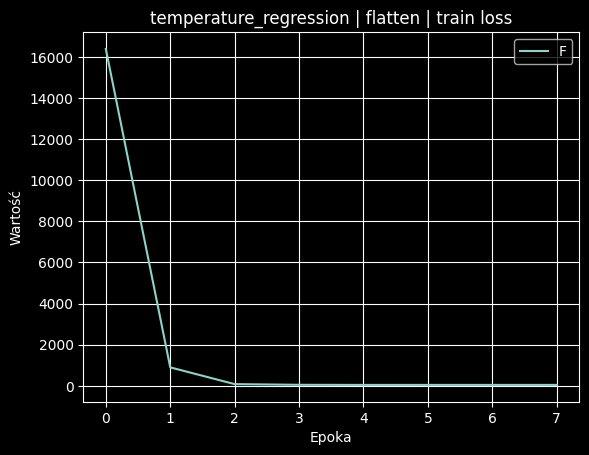


WINDOW AGGREGATION MODE: AGGREGATE
Train shape: X=(2909, 6), y=(2909, 1)
Test  shape: X=(689, 6), y=(689, 1)

--- EXPERIMENT: temperature_regression ---

Loss=mse, Epochs=20, Activation=sigmoid, Optimizer=momentum
>>> Initializing MLP...
Layer sizes: [6, 128, 64, 1], Task: regression, Activation: sigmoid, Optimizer: momentum
>>> Version 16 (mini-batch + early stopping)...
[epoch     1/20] loss=16105.009513 lr=0.01
[epoch     2/20] loss=877.700472 lr=0.01
[epoch     3/20] loss=70.653563 lr=0.01
[epoch     4/20] loss=49.853524 lr=0.01
[epoch     5/20] loss=43.309573 lr=0.01
[epoch     6/20] loss=44.123513 lr=0.01
[epoch     7/20] loss=43.970514 lr=0.01
[epoch     8/20] loss=43.978718 lr=0.01
Early stopping at epoch 8, best val_loss=23.287924 after 5 epochs without improvement.
Training finished in 0.38 seconds
Test MSE: 65.073035


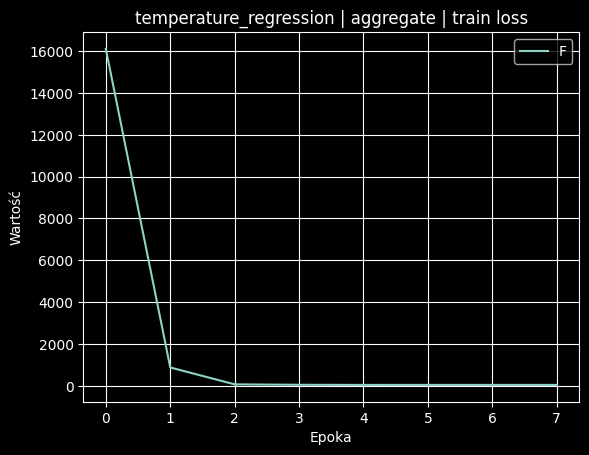

In [8]:
from copy import deepcopy
import numpy as np
from mlp.mlp import MLP
from mlp.utils import plot_loss
from weather.dataset import build_dataset
from weather.normalization import normalize_global

results = {}

for mode in ["flatten", "aggregate"]:
    print("\n" + "=" * 80)
    print(f"WINDOW AGGREGATION MODE: {mode.upper()}")
    print("=" * 80)

    cfg = deepcopy(base_cfg)
    cfg.window_aggregation = mode

    # --- TRAIN DATASET ---
    cfg.split = "train"
    X_train, y_train = build_dataset(cfg, verbose=False)
    X_train, mu, sigma = normalize_global(X_train)

    # --- TEST DATASET ---
    cfg.split = "test"
    X_test, y_test = build_dataset(cfg, verbose=False)
    X_test = (X_test - mu) / sigma  # ta sama normalizacja

    print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
    print(f"Test  shape: X={X_test.shape}, y={y_test.shape}")

    results[mode] = {}

    for exp_name, exp in experiments.items():
        print(f"\n--- EXPERIMENT: {exp_name} ---")

        n_inputs = X_train.shape[1]

        for loss_name in exp["losses"]:
            for n_epochs in exp["epochs"]:

                print(
                    f"\nLoss={loss_name}, "
                    f"Epochs={n_epochs}, "
                    f"Activation={exp['activation']}, "
                    f"Optimizer={exp['optimizer']}"
                )

                model = MLP(
                    layer_sizes=[n_inputs, *exp["hidden_layers"], 1],
                    task=exp["task"],
                    activation=exp["activation"],
                    learning_rate=exp["learning_rate"],
                    seed=SEED,
                    loss=loss_name,
                    optimizer=exp["optimizer"],
                    adaptive_lr=exp["adaptive_lr"],
                )

                history, _, _ = model.fit(
                    X_train,
                    y_train,
                    epochs=n_epochs,
                    batch_size=exp["batching"]["minibatch_auto"]["batch_size"],
                    shuffle=exp["batching"]["minibatch_auto"]["shuffle"],
                    verbose=True,
                    use_tqdm=False,
                    early_stopping=exp["early_stopping"],
                    patience=exp["patience"],
                )

                # --- TEST LOSS ---
                test_loss = model.compute_loss(X_test, y_test)
                print(f"Test MSE: {test_loss:.6f}")

                results[mode][exp_name] = {
                    "train_loss": history,
                    "test_loss": test_loss,
                }

                plot_loss(
                    history,
                    title=f"{exp_name} | {mode} | train loss"
                )
